In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 3.
# Автоподбор ETS: AICc против кросс-валидации

У `AutoETS` есть встроенный способ выбрать
лучшую спецификацию: **информационный критерий** (AICc). Это быстро — модель
сама подбирает себя за доли секунды. Но что если этому не доверять и вместо
этого честно перебрать все спецификации, оценивая каждую **кросс-валидацией** —
то есть тем способом, которым мы на самом деле собираемся использовать модель?
Совпадут ли ответы? И какова цена честности в секундах?

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 1 | Как `AutoETS` выбирает спецификацию по AICc и можно ли повторить это руками |
| 2 | Как устроена кросс-валидация временных рядов в `statsforecast` |
| 3 | Что выберут AICc и CV на одном и том же ряде — и куда уходит время |
| 4 | То же самое сравнение в `sktime`, чтобы увидеть общую картину, а не особенность одной библиотеки |

> **Соглашение об оформлении.** Блоки, начинающиеся с 🔍, — это то, на что стоит
> обратить внимание особо: там прячутся типичные ошибки новичков.

---
# 0. Импорты и данные

In [1]:
import time
import warnings
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# --- statsforecast: модели и оркестратор ---
import statsforecast

# --- utilsforecast: графики и метрики качества ---
import utilsforecast
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mase, rmse
from utilsforecast.plotting import plot_series

# mase требует seasonality (длину сезонного лага для наивного бенчмарка);
# фиксируем её под наши помесячные данные, чтобы передавать в evaluate как обычную метрику
# (utilsforecast сам умеет доставать имя метрики из functools.partial).
mase12 = partial(mase, seasonality=12)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

print("statsforecast: ", statsforecast.__version__)
print("utilsforecast: ", utilsforecast.__version__)
print("pandas:        ", pd.__version__)

statsforecast:  2.1.1
utilsforecast:  0.2.16
pandas:         2.3.3


Тот же сквозной пример, что и в ноутбуке `04`, — `AirPassengers` (число
пассажиров авиалиний, 1949–1960, помесячно, месячная сезонность `m=12`).
Приводим данные к длинному формату `unique_id / ds / y`.

Всего наблюдений: 144 | train: 132 | test: 12


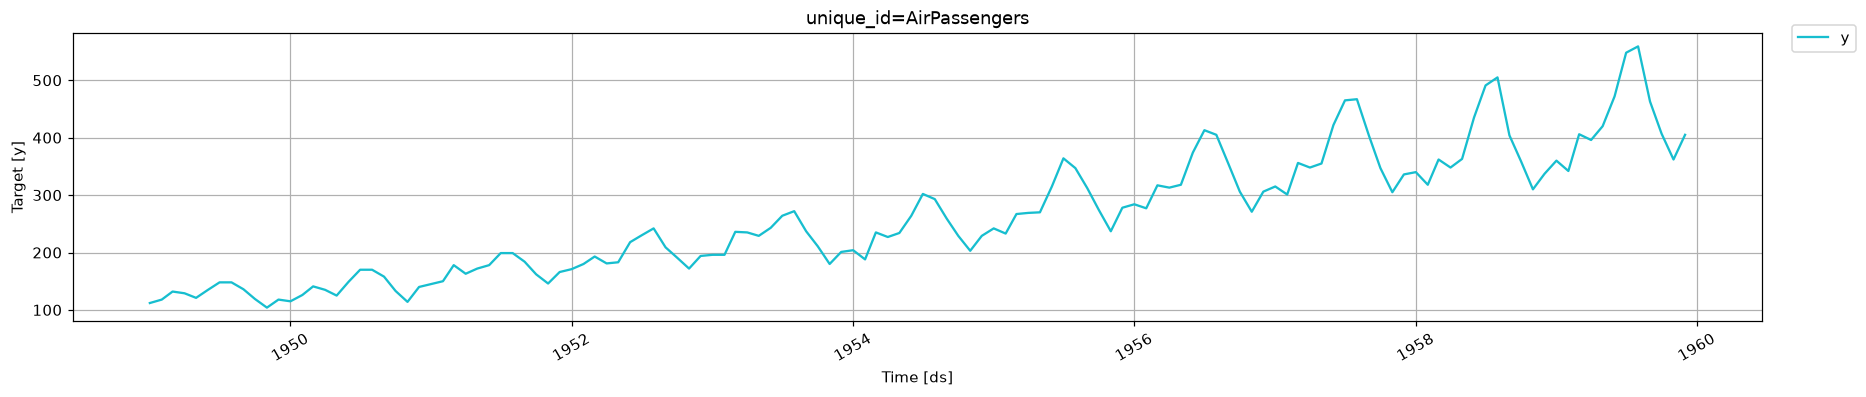

In [2]:
raw = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/airline-passengers.csv",
    parse_dates=["Month"],
)

air = raw.rename(columns={"Month": "ds", "Passengers": "y"}).assign(unique_id="AirPassengers")[
    ["unique_id", "ds", "y"]
]

h = 12  # горизонт прогноза — год вперёд
air_train, air_test = air.iloc[:-h].copy(), air.iloc[-h:].copy()

print("Всего наблюдений:", len(air), "| train:", len(air_train), "| test:", len(air_test))
plot_series(air_train, forecasts_df=None)

---
# 1. `AutoETS`: подбор по информационному критерию

## 1.1. Что перебирает `AutoETS(model='ZZZ')`

Строка `model` в `statsforecast.AutoETS` — это три буквы: **E**rror, **T**rend,
**S**easonality. Каждая принимает одно из значений:

| Буква | Значения | Смысл |
|---|---|---|
| Error (1-я буква) | `A`, `M` | аддитивная или мультипликативная ошибка |
| Trend (2-я буква) | `N`, `A`, `M` | нет тренда / аддитивный / мультипликативный |
| Season (3-я буква) | `N`, `A`, `M` | нет сезонности / аддитивная / мультипликативная |
| `damped` (отдельный параметр) | `True`, `False` | демпфировать тренд (актуально, если тренд не `N`) |

`Z` в любой позиции означает «подбери сам»: `model='ZZZ'` — полный перебор,
`model='AZN'` — ошибка зафиксирована аддитивной, сезонности нет, тренд подбирается.
С `damped=None` (по умолчанию) перебираются обе версии тренда — с демпфированием
и без.

Комбинаций много, но не все допустимы: например, мультипликативный тренд при
аддитивной ошибке считается неустойчивым и по умолчанию исключён параметром
`restrict=True` (это внутренняя настройка `ets_f`, наружу в конструкторе
`AutoETS` не вынесена). 🔍 Даже без ограничений часть комбинаций просто не
сходится на конкретных данных — `AutoETS` в этом случае молча их пропускает.

## 1.2. AIC, AICc, BIC — как автомат сравнивает модели

Все три критерия штрафуют модель за число параметров, чтобы не выбрать самую
сложную спецификацию просто потому, что она точнее описывает обучающую выборку:

$$
\mathrm{AIC} = -2\log L + 2k, \qquad
\mathrm{AICc} = \mathrm{AIC} + \frac{2k(k+1)}{n-k-1}, \qquad
\mathrm{BIC} = -2\log L + k\log n,
$$

где $L$ — правдоподобие обученной модели, $k$ — число параметров (сглаживания + начальные состояния), $n$ — число наблюдений. AICc — это AIC с поправкой на
маленькую выборку: при росте $n$ поправка исчезает, а на коротких рядах (как
наш — 132 точки в train при 15–18 параметрах у сезонных моделей) она заметна.
BIC штрафует параметры сильнее AIC/AICc, особенно на длинных рядах, и поэтому
обычно выбирает более простые модели.

🔍 `statsforecast.AutoETS` **всегда** выбирает по AICc — это зашито внутри
`ets_f` и не выведено в конструктор `AutoETS` как настраиваемый параметр
(сравните с `sktime.AutoETS`, где есть `information_criterion='aic'/'bic'/'aicc'`
— увидим это в разделе 4). Посчитать AIC/BIC самим моделям это не мешает: они
лежат в `model_` после обучения, и ничто не помешает нам отсортировать по ним
вручную.

## 1.3. Обучаем `AutoETS(model='ZZZ')` и читаем результат

In [3]:
sf_auto = StatsForecast(
    models=[AutoETS(season_length=12, alias="AutoETS_AICc")], freq="MS", n_jobs=1
)
sf_auto.fit(air_train)

auto_model = sf_auto.fitted_[0, 0].model_
print("Выбранная спецификация:", auto_model["method"])
print("Число параметров:", auto_model["n_params"])
print(pd.Series({k: auto_model[k] for k in ["loglik", "aic", "aicc", "bic"]}).round(2))

Выбранная спецификация: ETS(M,N,M)
Число параметров: 15
loglik    -631.66
aic       1293.33
aicc      1297.47
bic       1336.57
dtype: float64


`model_` — это словарь (аналог `summary()` в `statsmodels`, подробнее — см.
ноутбук `04`, раздел 1.2). Нам сегодня хватит трёх полей: `method` (какая
спецификация выбрана), `n_params` и сами критерии.

## 1.4. Воспроизводим автомат руками

Переберём вручную список содержательно разных спецификаций и убедимся, что
лучшая по AICc среди них совпадает с тем, что выбрал `model='ZZZ'`. Заодно эта
сетка спецификаций пригодится в разделе 3 — там мы прогоним её же через
кросс-валидацию.

In [4]:
import re

# Спецификации: код вида '[Error][Trend]d?[Season]', буква 'd' после тренда
# означает damped=True (например, 'AAdA' — аддитивная ошибка/тренд с демпфированием/
# аддитивная сезонность).
SPECS = [
    "ANN",
    "AAN",
    "AAdN",
    "AAA",
    "AAdA",
    "MNM",
    "MAM",
    "MAdM",
    "MNN",
    "MAN",
    "MAdN",
    "MMN",
    "MMM",
    "MMdM",
]

_SPEC_RE = re.compile(r"^([AM])([AMN])(d?)([AMN])$")


def make_ets(spec, season_length=12, alias=None):
    """Строит AutoETS с фиксированной (не 'Z') спецификацией по короткому коду вида 'MAdM'."""
    error, trend, damped_flag, season = _SPEC_RE.match(spec).groups()
    return AutoETS(
        season_length=season_length,
        model=f"{error}{trend}{season}",
        damped=bool(damped_flag),
        alias=alias or spec,
    )


def spec_to_components(spec):
    """Переводит наш короткий код ('MAdM') в формат model_['components'] ('MAMD')."""
    error, trend, damped_flag, season = _SPEC_RE.match(spec).groups()
    return f"{error}{trend}{season}{'D' if damped_flag else 'N'}"


rows = []
for spec in SPECS:
    model = make_ets(spec).fit(air_train["y"].to_numpy())
    md = model.model_
    rows.append(
        {
            "spec": spec,
            "method": md["method"],
            "n_params": md["n_params"],
            "loglik": md["loglik"],
            "aic": md["aic"],
            "aicc": md["aicc"],
            "bic": md["bic"],
        }
    )

ic_table = pd.DataFrame(rows).sort_values("aicc").reset_index(drop=True)
ic_table.round(2)

,spec,method,n_params,loglik,aic,aicc,bic
0,MNM,"ETS(M,N,M)",15,-631.66,1293.33,1297.47,1336.57
1,MMM,"ETS(M,M,M)",17,-658.34,1350.68,1356.05,1399.69
2,MAM,"ETS(M,A,M)",17,-661.81,1357.62,1362.99,1406.63
3,MMdM,"ETS(M,Md,M)",18,-679.14,1394.28,1400.33,1446.17
4,AAdA,"ETS(A,Ad,A)",18,-683.75,1403.50,1409.56,1455.39
5,MAdM,"ETS(M,Ad,M)",18,-694.04,1424.08,1430.13,1475.97
6,AAA,"ETS(A,A,A)",17,-723.19,1480.38,1485.75,1529.39
7,MAN,"ETS(M,A,N)",5,-749.16,1508.31,1508.79,1522.72
8,MNN,"ETS(M,N,N)",3,-751.50,1509.01,1509.19,1517.65
9,MMN,"ETS(M,M,N)",5,-750.13,1510.25,1510.73,1524.66


In [5]:
print(
    "Лучшая по AICc среди перебранных вручную:",
    ic_table.loc[0, "spec"],
    "->",
    ic_table.loc[0, "method"],
)
print("То, что выбрал AutoETS(model='ZZZ'):     ", auto_model["method"])

Лучшая по AICc среди перебранных вручную: MNM -> ETS(M,N,M)
То, что выбрал AutoETS(model='ZZZ'):      ETS(M,N,M)


Совпало — `ZZZ` внутри делает ровно такой же перебор по всем допустимым
комбинациям и сравнение по AICc, только полнее и без ручного списка.

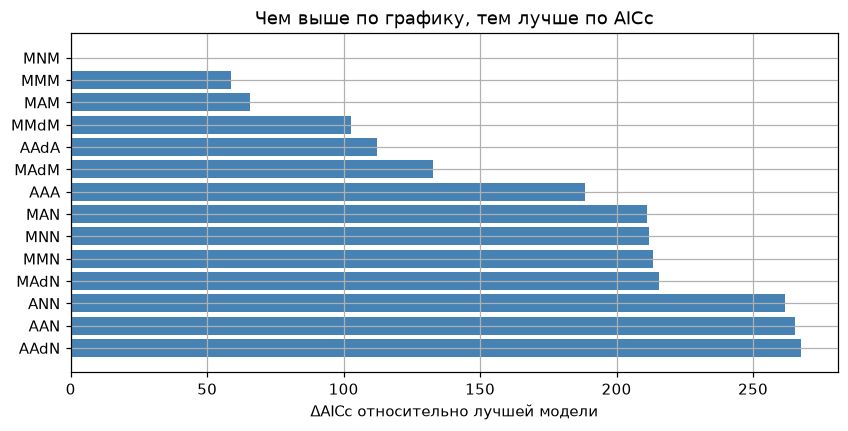

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
delta_aicc = ic_table["aicc"] - ic_table["aicc"].min()
ax.barh(ic_table["spec"], delta_aicc, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("ΔAICc относительно лучшей модели")
ax.set_title("Чем выше по графику, тем лучше по AICc")
plt.show()

## 1.5. 🔍 Ловушки при сравнении по информационному критерию

- **Сравнимо только «яблоки с яблоками».** AIC/AICc/BIC сравнимы только между
  моделями, обученными на **одних и тех же** данных (без разного логарифмирования
  или преобразования Бокса — Кокса целевой переменной) и одной и той же реализацией.
  Сравнивать AICc из `statsforecast` с AIC из `statsmodels` бессмысленно.
- **AIC и BIC не всегда согласны.** Отсортируйте `ic_table` по `bic` — из-за более
  сильного штрафа за параметры топ может быть другим (обычно более простым).
- **Частичная фиксация буквами, кроме `Z`.** `model='AZN'` подберёт только тренд,
  зафиксировав аддитивную ошибку и отсутствие сезонности — полезно, если про ряд
  заранее что-то известно (например, сезонности точно нет).
- **`damped` без тренда не имеет смысла** — демпфируется именно тренд; для
  `model='*N*'` (тренда нет) параметр `damped` игнорируется.

In [7]:
ic_table.sort_values("bic").reset_index(drop=True).round(2)

,spec,method,n_params,loglik,aic,aicc,bic
0,MNM,"ETS(M,N,M)",15,-631.66,1293.33,1297.47,1336.57
1,MMM,"ETS(M,M,M)",17,-658.34,1350.68,1356.05,1399.69
2,MAM,"ETS(M,A,M)",17,-661.81,1357.62,1362.99,1406.63
3,MMdM,"ETS(M,Md,M)",18,-679.14,1394.28,1400.33,1446.17
4,AAdA,"ETS(A,Ad,A)",18,-683.75,1403.50,1409.56,1455.39
5,MAdM,"ETS(M,Ad,M)",18,-694.04,1424.08,1430.13,1475.97
6,MNN,"ETS(M,N,N)",3,-751.50,1509.01,1509.19,1517.65
7,MAN,"ETS(M,A,N)",5,-749.16,1508.31,1508.79,1522.72
8,MMN,"ETS(M,M,N)",5,-750.13,1510.25,1510.73,1524.66
9,AAA,"ETS(A,A,A)",17,-723.19,1480.38,1485.75,1529.39


---
# 2. Кросс-валидация в `statsforecast` (коротко)

## 2.1. Почему не обычный `KFold`

У временного ряда наблюдения упорядочены, и модель прогнозирует **будущее по
прошлому**. Если раскидать точки по фолдам случайно (как в `KFold`), модель
при обучении увидит будущее по отношению к своему же тесту — это утечка данных,
и оценка качества окажется завышенной и бесполезной.

Правильная схема — **скользящее (расширяющееся) окно**: точка отсечки `cutoff`
сдвигается вперёд по ряду, каждый раз модель обучается только на данных до
`cutoff` и прогнозирует `h` точек вперёд. Ниже — четыре таких окна на train:

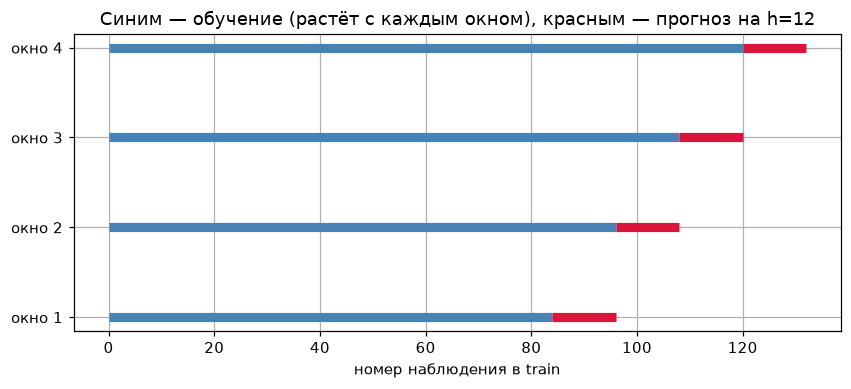

In [8]:
n_windows, step_size = 4, h
cutoffs_demo = [len(air_train) - step_size * i - h for i in range(n_windows)][::-1]

fig, ax = plt.subplots(figsize=(9, 3.5))
for i, cutoff in enumerate(cutoffs_demo):
    ax.plot([0, cutoff], [i, i], color="steelblue", linewidth=6, solid_capstyle="butt")
    ax.plot([cutoff, cutoff + h], [i, i], color="crimson", linewidth=6, solid_capstyle="butt")
ax.set_yticks(range(n_windows))
ax.set_yticklabels([f"окно {i + 1}" for i in range(n_windows)])
ax.set_xlabel("номер наблюдения в train")
ax.set_title(f"Синим — обучение (растёт с каждым окном), красным — прогноз на h={h}")
plt.show()

## 2.2. `sf.cross_validation`

Всё это делает один вызов `StatsForecast.cross_validation(df, h, n_windows,
step_size, refit)`:

- `h` — горизонт прогноза в каждом окне;
- `n_windows` — сколько окон отсчитать назад от конца ряда;
- `step_size` — на сколько шагов сдвигается `cutoff` между окнами (при
  `step_size < h` окна перекрываются);
- `refit` — переобучать ли модель заново на каждом окне (`True`, по умолчанию)
  или обучить один раз на первом окне и только прогонять вперёд (`False`,
  быстрее, но менее честно) — либо переобучать раз в `N` окон, если передать
  целое число.

In [9]:
sf_cv_demo = StatsForecast(
    models=[AutoETS(season_length=12, alias="AutoETS_AICc")], freq="MS", n_jobs=1
)
cv_demo = sf_cv_demo.cross_validation(df=air_train, h=h, n_windows=n_windows, step_size=step_size)

print("Строк:", len(cv_demo), "| окон (уникальных cutoff):", cv_demo["cutoff"].nunique())
cv_demo.head()

Строк: 48 | окон (уникальных cutoff): 4


,unique_id,ds,cutoff,y,AutoETS_AICc
0,AirPassengers,1956-01-01,1955-12-01,284.0,270.667603
1,AirPassengers,1956-02-01,1955-12-01,277.0,273.092773
2,AirPassengers,1956-03-01,1955-12-01,317.0,314.655609
3,AirPassengers,1956-04-01,1955-12-01,313.0,299.682404
4,AirPassengers,1956-05-01,1955-12-01,318.0,295.898285


В каждой строке — реальное значение `y`, прогноз модели и `cutoff`, на котором
модель была обучена. Это тот же формат, который возвращает `sf.forecast`, плюс
столбец `cutoff`.

## 2.3. Метрики по окнам

`utilsforecast.evaluate` умеет считать метрику по каждому `unique_id` и окну и
агрегировать (например, усреднять по окнам, если передать `agg_fn='mean'`).

In [10]:
cv_metrics_demo = evaluate(cv_demo.drop(columns="cutoff"), metrics=[rmse, mae], agg_fn="mean")
cv_metrics_demo

,metric,AutoETS_AICc
0,rmse,38.301182
1,mae,31.032320


🔍 Метрика `mase` (масштабированная относительно наивного прогноза) требует
ещё двух аргументов: `train_df` (откуда считается масштаб) и `seasonality`
(длину сезонного лага для наивного бенчмарка). Второй параметр удобно
зафиксировать заранее через `functools.partial` — так и получилась `mase12`
в разделе 0. Мы воспользуемся этим в разделе 3:
`evaluate(cv_demo.drop(columns="cutoff"), metrics=[mase12], train_df=air_train, agg_fn="mean")`.

---
# 3. Честное сравнение: выбор по AICc против выбора по CV

## 3.1. Протокол сравнения

Чтобы сравнение было честным, отложенные последние `h=12` точек (`air_test`)
не должны участвовать в **выборе** модели — иначе мы просто подгоним модель под
тест, а это и есть подсматривание в будущее (data leakage). Схема:

| Шаг | Стратегия A: AICc | Стратегия B: кросс-валидация |
|---|---|---|
| Что видит при выборе | только `air_train`, критерий AICc | только `air_train`, `n_windows=4` окна |
| Как выбирает | `AutoETS(model='ZZZ')` — один вызов | сетка `SPECS` из раздела 1.4, ранжирование по CV-RMSE |
| Итоговая проверка | прогноз выбранной модели на `air_test` | прогноз выбранной модели на `air_test` |

И только после того как обе стратегии выбрали свою «лучшую» модель, мы один раз
смотрим на `air_test` — и не трогаем его больше.

## 3.2. Стратегия A — `AutoETS(model='ZZZ')`

In [11]:
t0 = time.perf_counter()
sf_strategy_a = StatsForecast(
    models=[AutoETS(season_length=12, alias="AutoETS_AICc")], freq="MS", n_jobs=1
)
sf_strategy_a.fit(air_train)
time_a = time.perf_counter() - t0

spec_a = sf_strategy_a.fitted_[0, 0].model_["method"]
print(f"Стратегия A выбрала {spec_a} за {time_a:.3f} с")

Стратегия A выбрала ETS(M,N,M) за 0.047 с


## 3.3. Стратегия B — сетка `SPECS`, оценённая кросс-валидацией

In [12]:
t0 = time.perf_counter()
grid_models = [make_ets(spec) for spec in SPECS]
sf_strategy_b_cv = StatsForecast(models=grid_models, freq="MS", n_jobs=1)
grid_cv = sf_strategy_b_cv.cross_validation(
    df=air_train, h=h, n_windows=n_windows, step_size=step_size
)
time_b_search = time.perf_counter() - t0

cv_ranking = (
    evaluate(grid_cv.drop(columns="cutoff"), metrics=[rmse], agg_fn="mean")
    .drop(columns="metric")
    .T.rename(columns={0: "cv_rmse"})
    .sort_values("cv_rmse")
)
cv_ranking["cv_rank"] = range(1, len(cv_ranking) + 1)

spec_a = ic_table.set_index("spec")[["aicc"]].sort_values("aicc").index[0]
spec_b = cv_ranking.index[0]
print(
    f"Стратегия B выбрала {spec_b} за {time_b_search:.3f} с (перебор {len(SPECS)} спецификаций × {n_windows} окон)"
)
cv_ranking

Стратегия B выбрала MAM за 0.166 с (перебор 14 спецификаций × 4 окон)


,cv_rmse,cv_rank
MAM,26.991911,1
MMdM,27.194614,2
MMM,27.840019,3
MAdM,30.525120,4
AAdA,36.524055,5
AAA,38.049328,6
MNM,38.301182,7
MMN,66.668510,8
MAN,70.301514,9
AAN,77.634148,10


Сведём обе оценки в одну таблицу: ранг по AICc (раздел 1.4) против ранга по
CV-RMSE. Если бы AICc и кросс-валидация были согласны, ранги совпадали бы
почти по диагонали.

In [13]:
comparison = (
    ic_table.set_index("spec")[["aicc"]]
    .assign(aicc_rank=lambda d: d["aicc"].rank().astype(int))
    .join(cv_ranking[["cv_rmse", "cv_rank"]])
    .sort_values("aicc_rank")
)
comparison

,aicc,aicc_rank,cv_rmse,cv_rank
spec,,,,
MNM,1297.466544,1,38.301182,7
MMM,1356.048949,2,27.840019,3
MAM,1362.993210,3,26.991911,1
MMdM,1400.333002,4,27.194614,2
AAdA,1409.556087,5,36.524055,5
MAdM,1430.133917,6,30.525120,4
AAA,1485.746567,7,38.049328,6
MAN,1508.786285,8,70.301514,9
MNN,1509.192986,9,86.960175,14


Модель, лучшая по AICc, не обязана занимать первое место по кросс-валидации,
а лучшая по CV-RMSE — не обязана быть первой по AICc. Ранги расходятся:
критерий, посчитанный по всей истории, и ошибка на будущих горизонтах — это
разные вещи, и совпадать они не обязаны.

In [14]:
print(
    f"AICc поставил {spec_a!r} на CV-ранг {int(comparison.loc[spec_a, 'cv_rank'])}"
    f" из {len(comparison)}."
)
print(
    f"CV поставила первой {spec_b!r}, у неё AICc-ранг {int(comparison.loc[spec_b, 'aicc_rank'])}."
)

AICc поставил 'MNM' на CV-ранг 7 из 14.
CV поставила первой 'MAM', у неё AICc-ранг 3.


## 3.4. Итог: время подбора против качества на отложенном тесте

Теперь — и только теперь — обучаем обе выбранные модели на всём `air_train` и
один раз смотрим на `air_test`.

In [15]:
final_models = [
    make_ets(spec_a, alias="A_AICc"),
    make_ets(spec_b, alias="B_CV"),
]
sf_final = StatsForecast(models=final_models, freq="MS", n_jobs=1)
fc_final = sf_final.forecast(df=air_train, h=h)

final_eval = evaluate(
    fc_final.merge(air_test[["unique_id", "ds", "y"]], on=["unique_id", "ds"]),
    metrics=[rmse, mae, mase12],
    train_df=air_train,
)
final_eval = final_eval.set_index("metric").T
final_eval

metric,rmse,mae,mase
unique_id,AirPassengers,AirPassengers,AirPassengers
A_AICc,40.083621,35.612475,1.169539
B_CV,25.719995,19.721153,0.647657


In [16]:
summary_table = pd.DataFrame(
    {
        "стратегия": ["A: AICc", "B: кросс-валидация"],
        "выбранная модель": [spec_a, spec_b],
        "время подбора, с": [round(time_a, 3), round(time_b_search, 3)],
        "RMSE на тесте": [
            round(final_eval.loc["A_AICc", "rmse"], 2),
            round(final_eval.loc["B_CV", "rmse"], 2),
        ],
        "MASE на тесте": [
            round(final_eval.loc["A_AICc", "mase"], 3),
            round(final_eval.loc["B_CV", "mase"], 3),
        ],
    }
)
summary_table

,стратегия,выбранная модель,"время подбора, с",RMSE на тесте,MASE на тесте
0,A: AICc,MNM,0.047,40.08,1.170
1,B: кросс-валидация,MAM,0.166,25.72,0.648


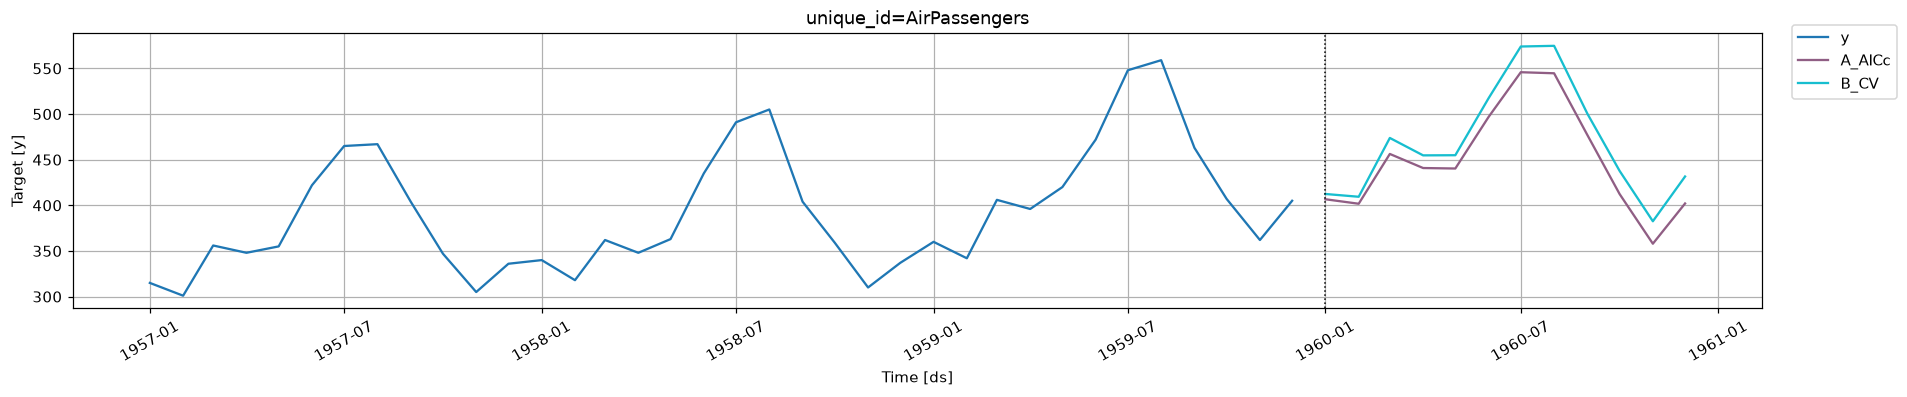

In [17]:
fig = plot_series(air_train, fc_final, max_insample_length=36)
fig.axes[0].axvline(air_test["ds"].min(), color="black", linestyle=":", linewidth=1)
fig

AICc отрабатывает на порядки быстрее — это разовый вызов `fit`. Кросс-валидация
стоит `len(SPECS) × n_windows` обучений (в нашем случае — 56), поэтому и заняла
заметно больше времени, зато оптимизирует именно то, что нас интересует: ошибку
прогноза на горизонте `h`, а не правдоподобие на всей истории. Плата за это —
не только время, но и риск переобучиться под конкретные 4 окна на коротком
ряде: с другим `n_windows` или `step_size` победитель мог бы оказаться другим.

🔍 На одном ряде и с небольшой сеткой разница во времени не критична. Ниже
посмотрим, что будет, если моделей и рядов станет больше.

## 3.5. Масштаб: сравнение на панели из 100 рядов

`../data/Monthly_sample.csv` — 2000 месячных рядов без дат в «широком» формате
(одна колонка = один ряд). Возьмём первые 100, приведём к длинному формату (как
в ноутбуке `04`, раздел 3.3), и прогоним обе стратегии уже на панели.

In [18]:
wide = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/Monthly_sample.csv",
    index_col=0,
).iloc[:, :100]
wide.index = pd.date_range("2000-01-01", periods=len(wide), freq="MS")

panel = (
    wide.reset_index(names="ds")
    .melt(id_vars="ds", var_name="unique_id", value_name="y")[["unique_id", "ds", "y"]]
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

h_panel = 12
panel_train = panel.groupby("unique_id", group_keys=False).apply(lambda d: d.iloc[:-h_panel])
panel_test = panel.groupby("unique_id", group_keys=False).apply(lambda d: d.iloc[-h_panel:])

print("Рядов:", panel["unique_id"].nunique(), "| строк в train:", len(panel_train))

Рядов: 100 | строк в train: 6500


In [19]:
t0 = time.perf_counter()
sf_panel_a = StatsForecast(
    models=[AutoETS(season_length=12, alias="AutoETS_AICc")], freq="MS", n_jobs=1
)
sf_panel_a = sf_panel_a.fit(panel_train)
fc_panel_a = sf_panel_a.predict(h=h_panel)
time_panel_a = time.perf_counter() - t0

panel_specs_a = pd.Series(
    {sid: sf_panel_a.fitted_[i, 0].model_["components"] for i, sid in enumerate(sf_panel_a.uids)}
)
print(f"Стратегия A на 100 рядах: {time_panel_a:.1f} с")

Стратегия A на 100 рядах: 2.8 с


In [20]:
t0 = time.perf_counter()
sf_panel_b = StatsForecast(models=[make_ets(spec) for spec in SPECS], freq="MS", n_jobs=1)
panel_cv = sf_panel_b.cross_validation(df=panel_train, h=h_panel, n_windows=3, step_size=h_panel)
time_panel_search = time.perf_counter() - t0

# Без agg_fn evaluate агрегирует только по окнам, оставляя строку на каждый ряд —
# это и нужно, чтобы для каждого ряда выбрать свою лучшую спецификацию.
panel_ranking = evaluate(panel_cv.drop(columns="cutoff"), metrics=[rmse], models=SPECS)
best_spec_per_series = panel_ranking.drop(columns="metric").set_index("unique_id").idxmin(axis=1)
print(
    f"Стратегия B на 100 рядах: {time_panel_search:.1f} с (перебор {len(SPECS)} спецификаций × 3 окна × 100 рядов)"
)

Стратегия B на 100 рядах: 6.3 с (перебор 14 спецификаций × 3 окна × 100 рядов)


In [21]:
# panel_specs_a хранит формат model_['components'] ('MNMN'), best_spec_per_series —
# наши короткие коды сетки ('MAM') — приводим их к общему формату перед сравнением.
best_spec_components = best_spec_per_series.map(spec_to_components)
agreement = (panel_specs_a.reindex(best_spec_components.index) == best_spec_components).mean()
print(f"Доля рядов, где обе стратегии выбрали одну и ту же спецификацию: {agreement:.0%}")

pd.DataFrame(
    {
        "стратегия": ["A: AICc", "B: кросс-валидация"],
        "время на 100 рядов, с": [round(time_panel_a, 1), round(time_panel_search, 1)],
        "время на 1 ряд, с": [round(time_panel_a / 100, 3), round(time_panel_search / 100, 3)],
    }
)

Доля рядов, где обе стратегии выбрали одну и ту же спецификацию: 23%


,стратегия,"время на 100 рядов, с","время на 1 ряд, с"
0,A: AICc,2.8,0.028
1,B: кросс-валидация,6.3,0.063


In [22]:
best_spec_per_series.value_counts().to_frame("число рядов")

,число рядов
MNM,14
ANN,13
AAdN,9
MNN,9
MAdN,8
AAdA,8
AAN,8
MMN,7
MAN,6
MAdM,5


На панели разрыв во времени между стратегиями растёт линейно от числа
кандидатов в сетке (`len(SPECS)`) и числа окон (`n_windows`) — при этом AICc
остаётся практически бесплатным. Стратегии часто выбирают разные спецификации
на одном и том же ряде: это ожидаемо, ведь они оптимизируют разные величины.
Насколько велика разница в итоговом качестве — предмет задания 5.

---
# 4. То же самое в `sktime` — сравнение инструментов

Чтобы убедиться, что расхождение AICc/CV — не особенность конкретной реализации,
повторим оба подхода в `sktime` (тот же инструмент, что и в ноутбуках `01`–`03`)
на исходном ряде `AirPassengers`. `sktime` работает с одним рядом за раз и хочет
`pandas.Series` с `PeriodIndex`.

In [23]:
from sktime.forecasting.ets import AutoETS as SktimeAutoETS
from sktime.forecasting.model_selection import ForecastingGridSearchCV
from sktime.performance_metrics.forecasting import MeanSquaredError
from sktime.split import ExpandingWindowSplitter

y = raw.set_index("Month")["Passengers"].astype(float)
y.index = pd.PeriodIndex(y.index, freq="M")
y_train, y_test = y.iloc[:-h], y.iloc[-h:]

## 4.1. `sktime.AutoETS(auto=True)` — выбор по информационному критерию

В отличие от `statsforecast`, здесь критерий явно настраивается параметром
`information_criterion` (по умолчанию — тоже `'aic'`, поставим `'aicc'` для
честного сравнения).

In [24]:
t0 = time.perf_counter()
sktime_auto = SktimeAutoETS(auto=True, sp=12, information_criterion="aicc", n_jobs=1)
sktime_auto.fit(y_train)
time_sktime_auto = time.perf_counter() - t0

print(
    f"sktime AutoETS выбрал: {sktime_auto.summary().tables[0].data[1][1]} за {time_sktime_auto:.2f} с"
)
sktime_auto.summary().tables[0]

sktime AutoETS выбрал: ETS(MAM) за 0.63 с


Dep. Variable:,Passengers,No. Observations:,132
Model:,ETS(MAM),Log Likelihood,-469.389
Date:,"Tue, 25 Aug 2026",AIC,974.778
Time:,09:40:52,BIC,1026.668
Sample:,01-31-1949,HQIC,995.864
,- 12-31-1959,Scale,0.001
Covariance Type:,approx,,


🔍 `sktime` выбрал другую спецификацию, чем `statsforecast` (`ETS(M,A,M)` против
`ETS(M,N,M)`), хотя оба используют AICc на одних и тех же данных. Дело в разных
реализациях оптимизатора и в разном наборе перебираемых по умолчанию комбинаций
— это не ошибка ни в одной из библиотек, а иллюстрация того, что «выбор по AICc»
не единственно возможный: он зависит от численной реализации не меньше, чем от
самого критерия.

## 4.2. `ForecastingGridSearchCV` — тот же перебор, но с кросс-валидацией

`sktime` не принимает строку `model='ZZZ'` — сетку задают явно словарём
параметров, а схему валидации — отдельным сплиттером.

In [25]:
grid = {
    "error": ["add", "mul"],
    "trend": ["add", "mul", None],
    "seasonal": ["add", "mul", None],
    "damped_trend": [True, False],
}
cv_splitter = ExpandingWindowSplitter(
    fh=list(range(1, h + 1)), initial_window=len(y_train) - 36, step_length=h
)

t0 = time.perf_counter()
sktime_gscv = ForecastingGridSearchCV(
    SktimeAutoETS(auto=False, sp=12),
    cv=cv_splitter,
    param_grid=grid,
    scoring=MeanSquaredError(square_root=True),
    n_jobs=1,
    error_score=np.nan,  # 🔍 без этого одна нерасходящаяся комбинация уронит весь перебор
)
sktime_gscv.fit(y_train)
time_sktime_gscv = time.perf_counter() - t0

print(
    f"sktime GridSearchCV выбрал: {sktime_gscv.best_params_} (RMSE={sktime_gscv.best_score_:.2f}) за {time_sktime_gscv:.2f} с"
)

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/utils/parallel.py:107: FitFailedWarning: 
                In evaluate, fitting of forecaster AutoETS failed,
                you can set error_score='raise' in evaluate to see
                the exception message.
                Fit failed for the 0-th data split, on training data y_train with
                cutoff NaT, and len(y_train)=96.
                The score will be set to nan.
                Failed forecaster with parameters: AutoETS(damped_trend=True, seasonal='mul', sp=12).
                
  ret = [fun(x, meta=meta) for x in iter]
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/utils/parallel.py:107: FitFailedWarning: 
                In evaluate, fitting of forecaster AutoETS failed,
                you can set error_score='raise' in evaluate to see
                the exception message.
                Fit failed f

sktime GridSearchCV выбрал: {'damped_trend': False, 'error': 'add', 'seasonal': 'mul', 'trend': 'add'} (RMSE=20.52) за 6.78 с


## 4.3. Свод: библиотека × стратегия

In [26]:
tools_summary = pd.DataFrame(
    {
        "инструмент": ["statsforecast", "statsforecast", "sktime", "sktime"],
        "стратегия": ["AICc", "кросс-валидация", "AICc", "кросс-валидация"],
        "время, с": [
            round(time_a, 3),
            round(time_b_search, 3),
            round(time_sktime_auto, 2),
            round(time_sktime_gscv, 2),
        ],
    }
)
tools_summary

,инструмент,стратегия,"время, с"
0,statsforecast,AICc,0.047
1,statsforecast,кросс-валидация,0.166
2,sktime,AICc,0.630
3,sktime,кросс-валидация,6.780


Картина повторяется в обеих библиотеках: подбор по информационному критерию на
порядки быстрее перебора с кросс-валидацией, а выбранная модель может отличаться
не только между стратегиями, но и между реализациями одной и той же стратегии.

---
# Итоги

## Что важно запомнить

1. **`AutoETS(model='ZZZ')` — это перебор по AICc**, а не магия: тот же результат
   можно получить вручную циклом по спецификациям и сортировкой по `model_['aicc']`.
2. **AICc — не единственный способ выбрать модель.** Он быстрый (один проход по
   всей истории), но оптимизирует правдоподобие *в прошлом*, а не ошибку прогноза
   *в будущем*. Кросс-валидация оптимизирует именно то, что нас интересует, ценой
   `n_кандидатов × n_windows` обучений.
3. **AICc и CV часто расходятся** — мы увидели это на `AirPassengers`: AICc выбрал
   `ETS(M,N,M)`, а CV по RMSE — `ETS(M,A,M)`, и это не редкий случай.
4. **Кросс-валидация временных рядов ≠ `KFold`.** Только расширяющееся/скользящее
   окно с `cutoff`, идущим вперёд по времени; иначе — утечка будущего.
5. **Выбор модели и финальная оценка — на разных данных.** Модель выбирают по
   `train` (по AICc или по внутренней CV), а на `test` только один раз проверяют
   результат — не подбирают по нему.
6. **Расхождение между реализациями — это нормально.** `statsforecast` и `sktime`
   выбрали разные модели даже при одинаковой стратегии (AICc) — численные детали
   оптимизатора и перебираемый набор кандидатов у них разные.


## Что дальше

Тот же вопрос — «AICc или кросс-валидация» — встанет ещё острее для `AutoARIMA`
(там пространство кандидатов больше) и для моделей, где кросс-валидация вообще
единственный способ подбора (например, `AutoMFLES` в `statsforecast` подбирает
гиперпараметры именно через внутреннюю hold-out-валидацию, а не через
информационный критерий). Это — тема будущих занятий по ARIMA и по нестатистическим
моделям.

---
# Задания для самостоятельной работы

**Задание 1 (BIC вместо AICc).** Отсортируйте `ic_table` из раздела 1.4 по `bic`
вместо `aicc`. Изменился ли победитель? Почему BIC теоретически должен выбирать
более простые модели, чем AIC/AICc?

**Задание 2 (`refit=False`).** Повторите кросс-валидацию из раздела 3.3 с
`refit=False` (модель обучается один раз на первом окне). Насколько это быстрее?
Изменился ли выбор лучшей спецификации? Что именно теряет `refit=False` по
сравнению с `refit=True`?
*Подсказка: посмотрите на документацию параметра `refit` в `cross_validation`
— что происходит с параметрами модели между окнами.*

**Задание 3 (сезонность суток и недели).** Загрузите `../data/ads.csv` (столбцы
`Time`, `Ads`, часовая частота). Постройте стратегию B (сетка + `cross_validation`)
отдельно для `season_length=24` и `season_length=168` и сравните итоговый RMSE
на отложенных последних 48 наблюдениях.
*Подсказка: не забудьте привести данные к формату `unique_id/ds/y` и задать `freq='h'`.*

**Задание 4\* (устойчивость к `n_windows`).** Повторите раздел 3.3 с
`n_windows=2` и `n_windows=8` вместо `4`. Остаётся ли победитель кросс-валидации
тем же самым? Что это говорит об устойчивости выбора модели по CV на коротких рядах?

**Задание 5\* (метрика имеет значение).** В разделе 3.5 мы ранжировали
спецификации по `rmse`. Пересчитайте `panel_ranking` по `mase12` (не забудьте
передать `train_df=panel_train`) — сильно ли изменится распределение выбранных
спецификаций по сравнению с `best_spec_per_series` из раздела 3.5?